# Predict Typologies for Real Buildings

This notebook uses the fine-tuned classifier to predict threshold typologies for real buildings (b1-b4).

**Pipeline:**
- Load fine-tuned classifier
- Load real building thresholds (b1-b4)
- Predict typology probabilities for each threshold
- Visualize and export results

## Setup

In [1]:
import os
import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt
from tqdm.auto import tqdm

from config_classifier import get_classifier_config
from classifier_model import ThresholdClassifier
from dataset_classifier import create_building_dataloader

print(f"PyTorch version: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    device = torch.device('cuda')
else:
    device = torch.device('cpu')
print(f"Device: {device}")

PyTorch version: 2.10.0.dev20251029+cu128
CUDA available: True
GPU: NVIDIA GeForce RTX 5060 Laptop GPU
Device: cuda


## Configuration

In [2]:
# Paths
PANOS_DIR = r"C:\Users\shrua\OneDrive\Desktop\threshold project\threshold\data\panos_buildings"
CANDIDATES_DIR = r"C:\Users\shrua\OneDrive\Desktop\threshold project\threshold\data\candidates"
MODEL_PATH = '../output_classifier/checkpoints/classifier_best.pt'
OUTPUT_DIR = '../output_classifier/building_predictions'

# Buildings to predict
BUILDING_IDS = ['b1', 'b2', 'b3', 'b4']

# Typology names
TYPOLOGY_NAMES = ['t1', 't2', 't3', 't4', 't5', 't6', 't7', 't8']

os.makedirs(OUTPUT_DIR, exist_ok=True)

print(f"Configuration:")
print(f"  Panos: {PANOS_DIR}")
print(f"  Candidates: {CANDIDATES_DIR}")
print(f"  Model: {MODEL_PATH}")
print(f"  Buildings: {BUILDING_IDS}")
print(f"  Output: {OUTPUT_DIR}")

Configuration:
  Panos: C:\Users\shrua\OneDrive\Desktop\threshold project\threshold\data\panos_buildings
  Candidates: C:\Users\shrua\OneDrive\Desktop\threshold project\threshold\data\candidates
  Model: ../output_classifier/checkpoints/classifier_best.pt
  Buildings: ['b1', 'b2', 'b3', 'b4']
  Output: ../output_classifier/building_predictions


## Load Fine-tuned Classifier

In [3]:
print("Loading fine-tuned classifier...")

# Load checkpoint (weights_only=False is safe for your own checkpoints)
checkpoint = torch.load(MODEL_PATH, map_location=device, weights_only=False)
config = checkpoint['config']

# Create model
model = ThresholdClassifier(config)
model.load_state_dict(checkpoint['model_state_dict'])
model = model.to(device)
model.eval()

print(f"✓ Model loaded successfully!")
print(f"  Trained epoch: {checkpoint['epoch']+1}")
print(f"  Val accuracy: {checkpoint['val_acc']:.2f}%")
print()

Loading fine-tuned classifier...
Loading pretrained encoder from: ../models_MAE/output_mae_adjusted/encoder_mae_pretrained.pt
MAE Configuration:
  Image: 32×64, 1 channel(s)
  Patch size: 8×8
  Patches per frame: 32 (4×8)
  Total frames: 7
  Total patches: 224
  Masking strategy: ASYMMETRIC
    Frames 0-1 (before): 90% masked
    Frames 2-4 (at threshold): 50% masked
    Frames 5-6 (after): 90% masked
  Average mask ratio: 72.9%
  Encoder: 6 layers, dim=384
  Decoder: 4 layers, dim=192
✓ Encoder frozen (linear probing mode)
✓ MLP Head: 384 → 128 → 8
✓ Model loaded successfully!
  Trained epoch: 13
  Val accuracy: 99.92%



## Load Building Data

In [4]:
print("Loading building thresholds...")

building_loader, building_dataset = create_building_dataloader(
    panos_dir=PANOS_DIR,
    candidates_dir=CANDIDATES_DIR,
    building_ids=BUILDING_IDS,
    batch_size=16,
    num_workers=0  # Use 0 to avoid multiprocessing issues on Windows
)

print(f"\n✓ Loaded {len(building_dataset)} threshold sequences from {len(BUILDING_IDS)} buildings")
print()

Loading building thresholds...
Loaded b1: 605 thresholds
Loaded b2: 899 thresholds
Loaded b3: 1183 thresholds
Loaded b4: 1090 thresholds
Total building thresholds: 3777

✓ Loaded 3777 threshold sequences from 4 buildings



## Predict Typologies

In [5]:
print("="*80)
print("PREDICTING TYPOLOGIES FOR REAL BUILDINGS")
print("="*80)
print()

# Collect predictions
predictions = []

with torch.no_grad():
    for batch in tqdm(building_loader, desc="Predicting"):
        imgs = batch['frames'].to(device)
        
        # Get predictions
        probs = model.predict_proba(imgs)  # [B, 8]
        preds = probs.argmax(dim=1)  # [B]
        
        # Get batch metadata (these are lists, not tensors)
        batch_size = imgs.size(0)
        building_ids = batch['building_id']
        threshold_ids = batch['threshold_id']
        frame_indices = batch['frame_indices']
        
        # Store results
        for i in range(batch_size):
            predictions.append({
                'building_id': building_ids[i],
                'threshold_id': threshold_ids[i],
                #'frame_indices': frame_indices[i],  # Already a list, no .tolist() needed
                'predicted_class': TYPOLOGY_NAMES[preds[i].item()],
                'confidence': probs[i, preds[i]].item(),
                **{f'{typ}_prob': probs[i, j].item() for j, typ in enumerate(TYPOLOGY_NAMES)}
            })

print(f"\n✓ Predictions complete! Total: {len(predictions)} thresholds")
print()

PREDICTING TYPOLOGIES FOR REAL BUILDINGS



Predicting:   0%|          | 0/237 [00:00<?, ?it/s]


✓ Predictions complete! Total: 3777 thresholds



## Export Predictions

In [6]:
# Convert to DataFrame
df_all = pd.DataFrame(predictions)

# Save all predictions
all_path = os.path.join(OUTPUT_DIR, 'all_predictions.csv')
df_all.to_csv(all_path, index=False)
print(f"✓ Saved all predictions to: {all_path}")
print()

# Save per-building
for building_id in BUILDING_IDS:
    df_building = df_all[df_all['building_id'] == building_id]
    if len(df_building) > 0:
        building_path = os.path.join(OUTPUT_DIR, f'{building_id}_predictions.csv')
        df_building.to_csv(building_path, index=False)
        print(f"✓ Saved {building_id}: {len(df_building)} thresholds → {building_path}")

print()
print("Prediction files created successfully!")

✓ Saved all predictions to: ../output_classifier/building_predictions\all_predictions.csv

✓ Saved b1: 605 thresholds → ../output_classifier/building_predictions\b1_predictions.csv
✓ Saved b2: 899 thresholds → ../output_classifier/building_predictions\b2_predictions.csv
✓ Saved b3: 1183 thresholds → ../output_classifier/building_predictions\b3_predictions.csv
✓ Saved b4: 1090 thresholds → ../output_classifier/building_predictions\b4_predictions.csv

Prediction files created successfully!


## Prediction Summary

In [7]:
print("="*80)
print("PREDICTION SUMMARY")
print("="*80)
print()

for building_id in BUILDING_IDS:
    df_building = df_all[df_all['building_id'] == building_id]
    if len(df_building) == 0:
        continue
    
    print(f"{building_id.upper()} ({len(df_building)} thresholds):")
    
    # Count predictions per typology
    pred_counts = df_building['predicted_class'].value_counts()
    for typ in TYPOLOGY_NAMES:
        count = pred_counts.get(typ, 0)
        pct = count / len(df_building) * 100
        print(f"  {typ}: {count:2d} ({pct:5.1f}%)")
    
    # Average confidence
    avg_conf = df_building['confidence'].mean()
    print(f"  Avg confidence: {avg_conf:.3f}")
    print()

print("="*80)
print()

PREDICTION SUMMARY

B1 (605 thresholds):
  t1: 356 ( 58.8%)
  t2: 247 ( 40.8%)
  t3:  1 (  0.2%)
  t4:  0 (  0.0%)
  t5:  0 (  0.0%)
  t6:  0 (  0.0%)
  t7:  0 (  0.0%)
  t8:  1 (  0.2%)
  Avg confidence: 0.910

B2 (899 thresholds):
  t1: 28 (  3.1%)
  t2: 692 ( 77.0%)
  t3:  0 (  0.0%)
  t4: 35 (  3.9%)
  t5: 31 (  3.4%)
  t6: 81 (  9.0%)
  t7:  9 (  1.0%)
  t8: 23 (  2.6%)
  Avg confidence: 0.923

B3 (1183 thresholds):
  t1: 20 (  1.7%)
  t2: 287 ( 24.3%)
  t3:  8 (  0.7%)
  t4: 206 ( 17.4%)
  t5:  3 (  0.3%)
  t6: 98 (  8.3%)
  t7: 230 ( 19.4%)
  t8: 331 ( 28.0%)
  Avg confidence: 0.885

B4 (1090 thresholds):
  t1: 12 (  1.1%)
  t2: 1066 ( 97.8%)
  t3:  0 (  0.0%)
  t4:  0 (  0.0%)
  t5:  9 (  0.8%)
  t6:  0 (  0.0%)
  t7:  0 (  0.0%)
  t8:  3 (  0.3%)
  Avg confidence: 0.970




## Visualize Predictions by Building

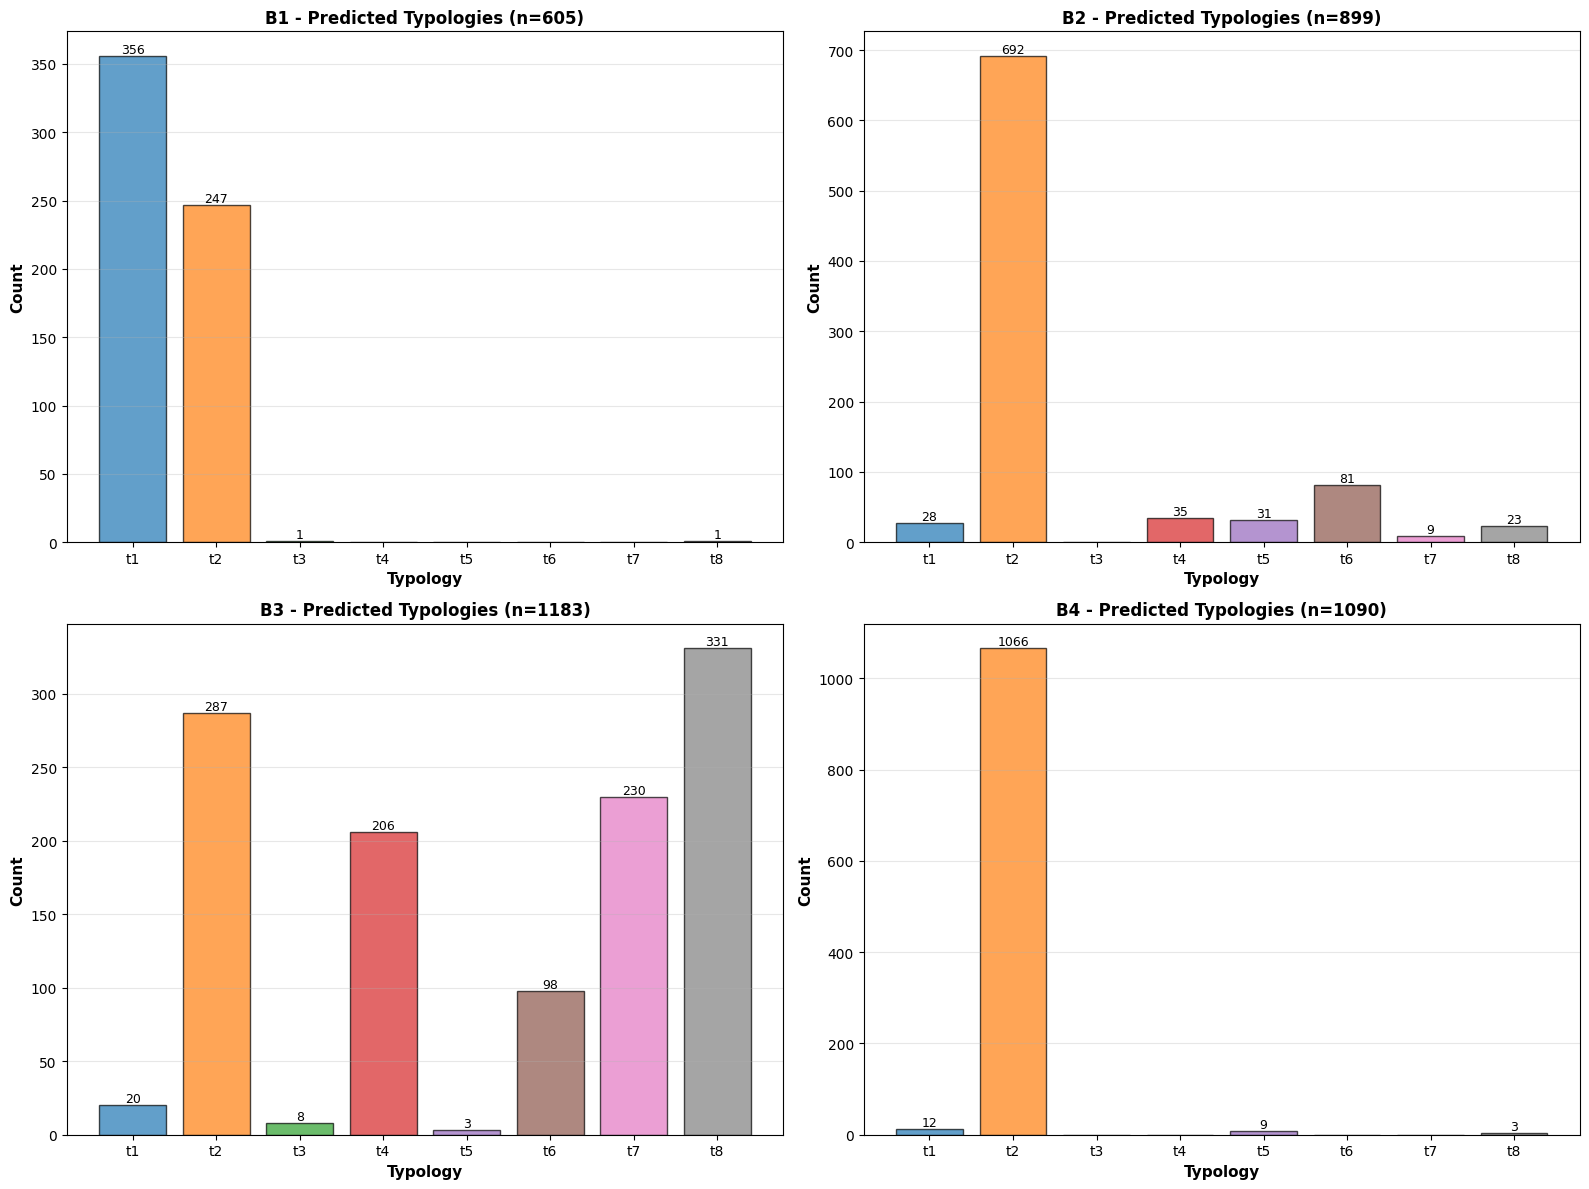

Summary visualization saved to: ../output_classifier/building_predictions\building_predictions_summary.png


In [8]:
# Create bar chart for each building
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
axes = axes.flatten()

for idx, building_id in enumerate(BUILDING_IDS):
    ax = axes[idx]
    df_building = df_all[df_all['building_id'] == building_id]
    
    if len(df_building) == 0:
        ax.text(0.5, 0.5, f'{building_id}\nNo data', 
                ha='center', va='center', fontsize=14)
        ax.set_xticks([])
        ax.set_yticks([])
        continue
    
    # Count predictions
    pred_counts = df_building['predicted_class'].value_counts().reindex(
        TYPOLOGY_NAMES, fill_value=0
    )
    
    # Plot
    bars = ax.bar(TYPOLOGY_NAMES, pred_counts.values, alpha=0.7, edgecolor='black')
    
    # Color bars by typology
    colors = plt.cm.tab10(np.linspace(0, 1, 10))[:8]
    for bar, color in zip(bars, colors):
        bar.set_facecolor(color)
    
    ax.set_xlabel('Typology', fontsize=11, fontweight='bold')
    ax.set_ylabel('Count', fontsize=11, fontweight='bold')
    ax.set_title(f'{building_id.upper()} - Predicted Typologies (n={len(df_building)})', 
                 fontsize=12, fontweight='bold')
    ax.grid(True, alpha=0.3, axis='y')
    
    # Add count labels on bars
    for bar in bars:
        height = bar.get_height()
        if height > 0:
            ax.text(bar.get_x() + bar.get_width()/2., height,
                   f'{int(height)}',
                   ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'building_predictions_summary.png'), 
            dpi=150, bbox_inches='tight')
plt.show()

print(f"Summary visualization saved to: {os.path.join(OUTPUT_DIR, 'building_predictions_summary.png')}")

## Top-1 and Top-3 Predictions by Building

TOP-1 AND TOP-3 PREDICTIONS BY BUILDING



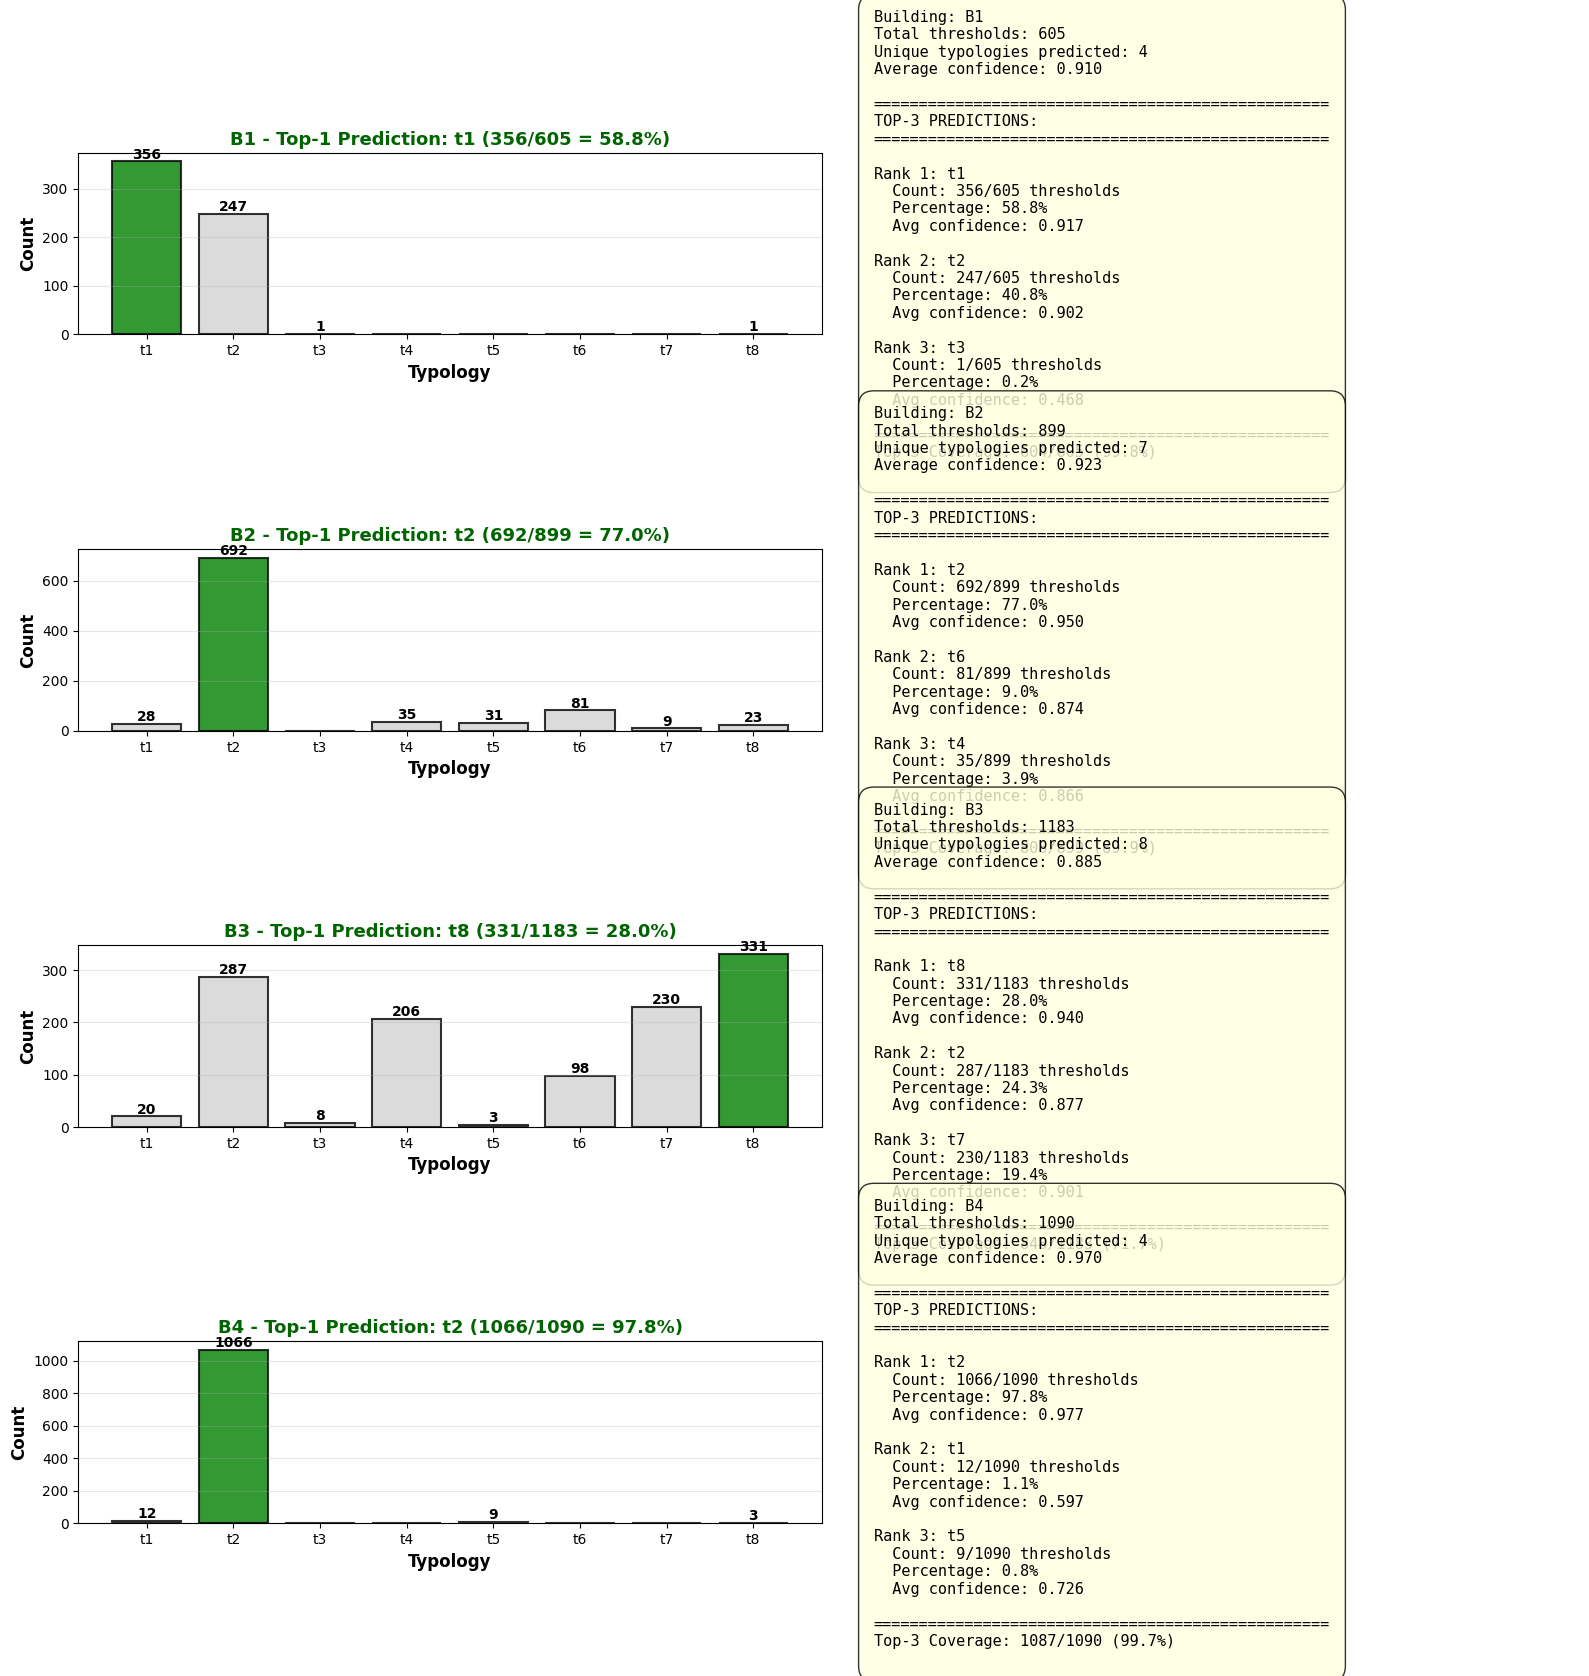


Top-1 and Top-3 predictions saved to: ../output_classifier/building_predictions\top_predictions.png

TOP-1 PREDICTIONS SUMMARY
B1: t1 (356/605 = 58.8%)
B2: t2 (692/899 = 77.0%)
B3: t8 (331/1183 = 28.0%)
B4: t2 (1066/1090 = 97.8%)

TOP-3 PREDICTIONS SUMMARY

B1:
  1. t1: 356 thresholds (58.8%)
  2. t2: 247 thresholds (40.8%)
  3. t3: 1 thresholds (0.2%)

B2:
  1. t2: 692 thresholds (77.0%)
  2. t6: 81 thresholds (9.0%)
  3. t4: 35 thresholds (3.9%)

B3:
  1. t8: 331 thresholds (28.0%)
  2. t2: 287 thresholds (24.3%)
  3. t7: 230 thresholds (19.4%)

B4:
  1. t2: 1066 thresholds (97.8%)
  2. t1: 12 thresholds (1.1%)
  3. t5: 9 thresholds (0.8%)



In [9]:
# Analyze top-1 and top-3 predictions for each building
print("="*80)
print("TOP-1 AND TOP-3 PREDICTIONS BY BUILDING")
print("="*80)
print()

# Create visualization
fig, axes = plt.subplots(len(BUILDING_IDS), 2, figsize=(16, 4*len(BUILDING_IDS)))

if len(BUILDING_IDS) == 1:
    axes = axes.reshape(1, -1)

for idx, building_id in enumerate(BUILDING_IDS):
    df_building = df_all[df_all['building_id'] == building_id]
    
    if len(df_building) == 0:
        axes[idx, 0].text(0.5, 0.5, f'{building_id}\nNo data', 
                          ha='center', va='center', fontsize=14)
        axes[idx, 0].set_xticks([])
        axes[idx, 0].set_yticks([])
        axes[idx, 1].axis('off')
        continue
    
    # Get prediction counts
    pred_counts = df_building['predicted_class'].value_counts()
    
    # Top-1: Most common prediction
    top1_class = pred_counts.index[0]
    top1_count = pred_counts.iloc[0]
    top1_pct = (top1_count / len(df_building)) * 100
    
    # Top-3: Three most common predictions
    top3_classes = pred_counts.head(3).index.tolist()
    top3_counts = pred_counts.head(3).values.tolist()
    top3_pcts = [(count / len(df_building)) * 100 for count in top3_counts]
    
    # Left subplot: Top-1 visualization
    ax = axes[idx, 0]
    
    # Show all typologies with top-1 highlighted
    all_counts = [pred_counts.get(typ, 0) for typ in TYPOLOGY_NAMES]
    colors = ['green' if typ == top1_class else 'lightgray' for typ in TYPOLOGY_NAMES]
    
    bars = ax.bar(TYPOLOGY_NAMES, all_counts, color=colors, alpha=0.8, edgecolor='black', linewidth=1.5)
    
    ax.set_xlabel('Typology', fontsize=12, fontweight='bold')
    ax.set_ylabel('Count', fontsize=12, fontweight='bold')
    ax.set_title(f'{building_id.upper()} - Top-1 Prediction: {top1_class} ({top1_count}/{len(df_building)} = {top1_pct:.1f}%)',
                 fontsize=13, fontweight='bold', color='darkgreen')
    ax.grid(True, alpha=0.3, axis='y')
    
    # Add count labels on bars
    for bar, count in zip(bars, all_counts):
        if count > 0:
            ax.text(bar.get_x() + bar.get_width()/2., count,
                   f'{int(count)}',
                   ha='center', va='bottom', fontsize=10, fontweight='bold')
    
    # Right subplot: Top-3 table and stats
    ax = axes[idx, 1]
    ax.axis('off')
    
    # Create info text
    info_text = f"Building: {building_id.upper()}\n"
    info_text += f"Total thresholds: {len(df_building)}\n"
    info_text += f"Unique typologies predicted: {len(pred_counts)}\n"
    info_text += f"Average confidence: {df_building['confidence'].mean():.3f}\n\n"
    info_text += "="*50 + "\n"
    info_text += "TOP-3 PREDICTIONS:\n"
    info_text += "="*50 + "\n\n"
    
    for rank, (typ, count, pct) in enumerate(zip(top3_classes, top3_counts, top3_pcts), 1):
        # Get average confidence for this typology
        typ_df = df_building[df_building['predicted_class'] == typ]
        avg_conf = typ_df['confidence'].mean() if len(typ_df) > 0 else 0
        
        info_text += f"Rank {rank}: {typ}\n"
        info_text += f"  Count: {count}/{len(df_building)} thresholds\n"
        info_text += f"  Percentage: {pct:.1f}%\n"
        info_text += f"  Avg confidence: {avg_conf:.3f}\n\n"
    
    # Coverage by top-3
    top3_total = sum(top3_counts)
    top3_coverage = (top3_total / len(df_building)) * 100
    info_text += "="*50 + "\n"
    info_text += f"Top-3 Coverage: {top3_total}/{len(df_building)} ({top3_coverage:.1f}%)\n"
    
    ax.text(0.05, 0.5, info_text, fontsize=11, verticalalignment='center',
           family='monospace',
           bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.8, pad=1))

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'top_predictions.png'), 
            dpi=150, bbox_inches='tight')
plt.show()

print(f"\nTop-1 and Top-3 predictions saved to: {os.path.join(OUTPUT_DIR, 'top_predictions.png')}")
print()

# Print summary table
print("="*80)
print("TOP-1 PREDICTIONS SUMMARY")
print("="*80)
for building_id in BUILDING_IDS:
    df_building = df_all[df_all['building_id'] == building_id]
    if len(df_building) == 0:
        continue
    
    pred_counts = df_building['predicted_class'].value_counts()
    top1_class = pred_counts.index[0]
    top1_count = pred_counts.iloc[0]
    top1_pct = (top1_count / len(df_building)) * 100
    
    print(f"{building_id.upper()}: {top1_class} ({top1_count}/{len(df_building)} = {top1_pct:.1f}%)")

print()
print("="*80)
print("TOP-3 PREDICTIONS SUMMARY")
print("="*80)
for building_id in BUILDING_IDS:
    df_building = df_all[df_all['building_id'] == building_id]
    if len(df_building) == 0:
        continue
    
    pred_counts = df_building['predicted_class'].value_counts()
    top3_classes = pred_counts.head(3)
    
    print(f"\n{building_id.upper()}:")
    for rank, (typ, count) in enumerate(top3_classes.items(), 1):
        pct = (count / len(df_building)) * 100
        print(f"  {rank}. {typ}: {count} thresholds ({pct:.1f}%)")

print("\n" + "="*80)

## Final Summary

In [10]:
print("="*80)
print("FINAL SUMMARY")
print("="*80)
print()
print(f"Buildings analyzed: {len(BUILDING_IDS)}")
print(f"Total thresholds predicted: {len(predictions)}")
print()
print("Output files:")
print(f"  All predictions: {os.path.join(OUTPUT_DIR, 'all_predictions.csv')}")
for building_id in BUILDING_IDS:
    building_path = os.path.join(OUTPUT_DIR, f'{building_id}_predictions.csv')
    if os.path.exists(building_path):
        print(f"  {building_id}: {building_path}")
print(f"  Summary plot: {os.path.join(OUTPUT_DIR, 'building_predictions_summary.png')}")
print()

# Overall statistics
print("Overall prediction distribution:")
overall_counts = df_all['predicted_class'].value_counts()
for typ in TYPOLOGY_NAMES:
    count = overall_counts.get(typ, 0)
    pct = count / len(df_all) * 100
    print(f"  {typ}: {count:3d} ({pct:5.1f}%)")
print()

print(f"Average confidence: {df_all['confidence'].mean():.3f}")
print(f"Min confidence: {df_all['confidence'].min():.3f}")
print(f"Max confidence: {df_all['confidence'].max():.3f}")
print()
print("="*80)
print("\n✓ Prediction complete! Results saved to:", OUTPUT_DIR)

FINAL SUMMARY

Buildings analyzed: 4
Total thresholds predicted: 3777

Output files:
  All predictions: ../output_classifier/building_predictions\all_predictions.csv
  b1: ../output_classifier/building_predictions\b1_predictions.csv
  b2: ../output_classifier/building_predictions\b2_predictions.csv
  b3: ../output_classifier/building_predictions\b3_predictions.csv
  b4: ../output_classifier/building_predictions\b4_predictions.csv
  Summary plot: ../output_classifier/building_predictions\building_predictions_summary.png

Overall prediction distribution:
  t1: 416 ( 11.0%)
  t2: 2292 ( 60.7%)
  t3:   9 (  0.2%)
  t4: 241 (  6.4%)
  t5:  43 (  1.1%)
  t6: 179 (  4.7%)
  t7: 239 (  6.3%)
  t8: 358 (  9.5%)

Average confidence: 0.923
Min confidence: 0.342
Max confidence: 1.000


✓ Prediction complete! Results saved to: ../output_classifier/building_predictions
